## How to load the model and predict with it

### 1- About the data:

The saved model was trained by the follwing data over the CONUS from Jan, 01, 2016 to Dec, 31, 2016:

 - Input forcing data: <a href="https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview"> ERA5 hourly data </a>
 - Target satellite soil moisture data: <a href="https://nsidc.org/data/spl3smp/versions/8">  SMAP L3 Radiometer Global Daily 36 km </a>

I saved the above data for year 2017 to demonstrate the structure of TERRAHydro database. To load them just run the following cells:

In [2]:
import xarray as xr

# forcing = xr.open_zarr('./Forcing.zarr')
smap = xr.open_zarr('SMAP.zarr')

And here is an example map of the forcing variable of temperature:

In [3]:
# forcing['t2m'][1,].plot()

And an example of the soil moisture map from the target data:

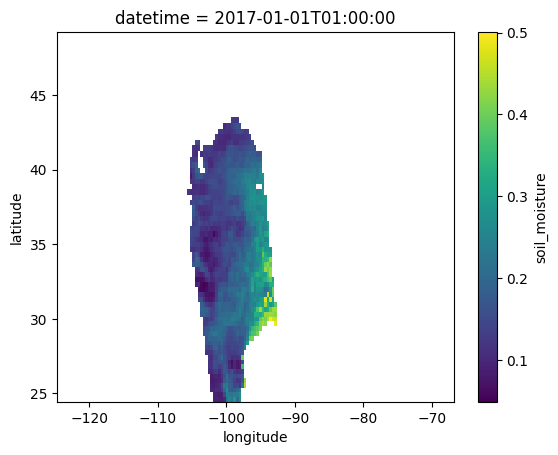

In [4]:
smap['soil_moisture'][1,].plot()

### 2- Load the data for model training/predicting:

In CREST / TERRAHydro we have a data pipeline that matches the pixels from all input/target data and get samples from.

Here we don't need that becasue we get the forcing data from another model. You may select a Lat/Long randomly within the CONUS and prepare the forcing data for a specific datetime.

But, if you want to get the forcing data for a pixel that we have sattelite soil moisture data for, you may use a function like below and get the coordinate info of that pixel:

In [5]:
import numpy as np

def get_sample_from_target(xda, # the xarray data array
                           n: int, # the number of pixels capturing from the data
                          ):

    n = 1
    found = 0
    results = []
    for t in range(len(xda.datetime)):
        xda_sel = xda.isel({'datetime': t})
        if int(xda_sel.count()) != 0:
    
            for index in np.ndindex(*xda_sel.shape):
                val = float(xda_sel[index])
                
                if not np.isnan(val):
                    coords = {dim: xda_sel.coords[dim].values[i] for dim, i in zip(xda_sel.dims, index)}
                    coords['datetime'] = xda_sel.datetime.values
                    val = {'soil_moisture': val}
                    results.append((coords, val))
                    found += 1
                if found == n:
                    break
        if found == n:
            break

    return results

For instance, here I get a pixel in the smap data along with its coordinates:

In [6]:
pixel_with_coords = get_sample_from_target(smap['soil_moisture'], 1)
pixel_with_coords

[({'latitude': 24.596555709838867,
   'longitude': -101.76348876953125,
   'datetime': numpy.datetime64('2017-01-01T01:00:00.000000000')},
  {'soil_moisture': 0.09220091253519058})]

### 3- Load the pre-trained model:

I have saved a Tensorflow model that gets the forcing data and predicts the soil_moisture. The model is not as accurate as the one that we have on TERRAHydro because we removed some input channels but I will try to prepare a more accurate model later.

To load the model just run the following line:

### (**please note that the model was saved using Tensorflow 2.10 and it is not going to work with the newer versions. You may use the environment_gpu.yaml file to make your env)

In [7]:
import tensorflow as tf
sm_model = tf.keras.models.load_model('sm_model')

### 4- Predict with the model:

The input data is a dict with the following forcing data (I already sent you the full name of them so I just write the abbreviates here):

In [8]:
forcing_attributes=['cape','cp','cvh','cvl','fal','lai_hv','lai_lv','msdwlwrf','msdwswrf',
                    'pev','skt','sp','ssr','ssrd','str','strd','stl1','stl2','stl3',
                    'stl4','t2m','d2m','tp','u10','v10','z','swvl1','slhf','e','csfr',
                    'es','smlt','sd']

The model expects each one of the attributes to be an array with the shape of (batch_size, time_length=48, latitude=1, longitude=1). As an example, I create a toy random sample of size (2, 48, 1, 1) and predict with it:

In [ ]:
example_data = {attr: np.random.random((2,48,1,1)) for attr in forcing_attributes}
sm_model.predict_on_batch(example_data)

{'soil_moisture': array([[-0.09577185],
        [-0.07122001]], dtype=float32)}

### * One last note: The forcing inputs were normalized with the following statistics file during the training:

In [10]:
stats = xr.open_dataset('stats.nc')
stats

<xarray.Dataset> Size: 32kB
Dimensions:        (statistics: 104)
Coordinates:
  * statistics     (statistics) <U6 2kB 'mean' 'std' 'min' ... 'p97' 'p98' 'p99'
Data variables: (12/35)
    cape           (statistics) float64 832B ...
    cp             (statistics) float64 832B ...
    csfr           (statistics) float64 832B ...
    cvh            (statistics) float64 832B ...
    cvl            (statistics) float64 832B ...
    d2m            (statistics) float64 832B ...
    ...             ...
    t2m            (statistics) float64 832B ...
    tp             (statistics) float64 832B ...
    u10            (statistics) float64 832B ...
    v10            (statistics) float64 832B ...
    z              (statistics) float64 832B ...
    soil_moisture  (statistics) float64 832B ...

### Any forcing data that is going to be used for model prediction should be normalized using the statistics file. You may use the following function for that:

In [11]:
def normalize_batch(data,
                   summary):

    stats = {k: [float(summary[k].to_dataset('statistics')['min']),
                 float(summary[k].to_dataset('statistics')['max']),
                 float(summary[k].to_dataset('statistics')['median']),
                 float(summary[k].to_dataset('statistics')['p25']),
                 float(summary[k].to_dataset('statistics')['p75']),
                ] for k in summary.keys()}

    for k, v in stats.items():
        stats[k].append((v[0] - v[2])/(v[4] - v[3] + 1e-10))
        stats[k].append((v[1] - v[2])/(v[4] - v[3] + 1e-10))

    # robust and normalize for es
    data = {k: (v - stats[k][0])/(stats[k][1] - stats[k][0] + 1e-10) if k=='es' else (v - stats[k][2])/(stats[k][4] - stats[k][3] + 1e-10) for k, v in data.items()}
    # normalize robust for all but es
    data = {k: v if k == 'es' else (v - stats[k][5])/(stats[k][6] - stats[k][5] + 1e-10) for k, v in data.items()}
    # scale normalize
    data = {k: v * (1 - (-1)) + (-1) for k, v in data.items()}
    
    return data

### and I normalize my example_data like this:

In [12]:
norm_example_data = normalize_batch(example_data, stats)